In [ ]:
!pip install datasets transformers sentence-transformers beautifulsoup4 lxml faiss-cpu torch scikit-learn pandas numpy
from datasets import load_dataset
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import re
from bs4 import BeautifulSoup
import pandas as pd
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
print("Instalado")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.0 MB/s eta 0:00:00
Instalado


In [ ]:
dataset_stream = load_dataset("natural_questions", split="validation", streaming=True)
subset_eval = []
for i, ex in enumerate(dataset_stream):
    if i >= 3000: break 
    subset_eval.append(ex)
    if i % 500 == 0: print(f"Cargados {i}")
print(f"Eval data: {len(subset_eval)} ejemplos")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

Cargados 0
Cargados 500
Cargados 1000
Cargados 1500
Cargados 2000
Cargados 2500
Eval data: 3000 ejemplos


In [ ]:
model_name = "deepset/roberta-base-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
qa_model = AutoModelForQuestionAnswering.from_pretrained(model_name)
print("QA model cargado")

def clean_html(doc_html):
    soup = BeautifulSoup(doc_html, 'lxml')
    for s in soup(['script', 'style', 'nav', 'header', 'footer']): s.decompose()
    text = soup.get_text(separator=' ', strip=True)[:4000]
    return text

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


QA model cargado


In [ ]:
def normalize_answer(text):
    if not text: return ""
    if isinstance(text, list): text = " ".join(str(t) for t in text)
    text = str(text).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    toks = text.split()
    return " ".join(toks)

def compute_f1(pred, gold):
    pred_toks = normalize_answer(pred).split()
    gold_toks = normalize_answer(gold).split()
    if not pred_toks or not gold_toks: return 0.0
    common = set(pred_toks) & set(gold_toks)
    p = len(common) / len(pred_toks)
    r = len(common) / len(gold_toks)
    if p + r == 0: return 0.0
    return 2 * p * r / (p + r)

def nq_f1_token(predictions, data):
    total_f1, count = 0, 0
    skipped = 0
    for pred in predictions:
        ex = next(e for e in data if e['id'] == pred['id'])
        ann = ex['annotations']
        short_answers = ann.get('short_answers', [])
        all_texts = []
        for sa in short_answers:
            texts = sa.get('text', [])
            if isinstance(texts, list):
                all_texts.extend(texts)
            else:
                all_texts.append(texts)
        gold_text = " ".join(all_texts)
        gold_words = [g.strip() for g in gold_text.split() if g.strip()]
        if not gold_words:
            skipped += 1
            continue
        pred_text = pred['prediction'].strip()
        max_f1 = max(compute_f1(pred_text, " ".join(gold_words)) for gold_words in [[" ".join(gold_words)]])
        total_f1 += max_f1
        count += 1
    print(f"Eval: {count} OK, {skipped} skipped")
    return total_f1 / count if count > 0 else 0.0


In [ ]:
def baseline_no_retrieve(question, context):
    inputs = tokenizer(question, context, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = qa_model(**inputs)
        start_idx = torch.argmax(outputs.start_logits)
        end_idx = torch.argmax(outputs.end_logits) + 1
        answer = tokenizer.decode(inputs["input_ids"][0][start_idx:end_idx])
    return answer

baselineA_preds = []
for i, ex in enumerate(subset_eval):
    q = ex["question"]["text"]
    context = clean_html(ex["document"]["html"])
    ans = baseline_no_retrieve(q, context)
    baselineA_preds.append({"id": ex["id"], "prediction": ans})
    if i % 500 == 0: print(f"A {i}")
f1A = nq_f1_token(baselineA_preds, subset_eval)
print(f"Baseline A F1: {f1A:.3f}")


A 0
A 500
A 1000
A 1500
A 2000
A 2500
Eval: 1646 OK, 1354 skipped
Baseline A F1: 0.086


In [6]:
def chunk_text(tokens, chunk_size=100):
    return [" ".join(tokens[i:i+chunk_size]) for i in range(0, len(tokens), chunk_size)]

In [ ]:
retriever = SentenceTransformer('sentence-transformers/multi-qa-MiniLM-L6-cos-v1')

def rag_controlled(question, doc_tokens, top_k=5):
    chunks = chunk_text(doc_tokens, 100)

    c_embs = retriever.encode(chunks)
    q_emb = retriever.encode([question])[0]

    scores = cosine_similarity([q_emb], c_embs)[0]
    top_idxs = np.argsort(scores)[-top_k:][::-1]

    selected = " ".join([chunks[i] for i in top_idxs])

    return baseline_no_retrieve(question, selected)

baselineB_preds = []
for i, ex in enumerate(subset_eval):
    q = ex["question"]["text"]
    doc_tokens = clean_html(ex["document"]["html"]).split()
    ans = rag_controlled(q, doc_tokens)
    baselineB_preds.append({"id": ex["id"], "prediction": ans})
    if i % 5000 == 0: print(f"Procesando B {i}")
f1B = nq_f1_token(baselineB_preds, subset_eval)
print(f"Baseline B F1: {f1B:.3f}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Procesando B 0
Eval: 1646 OK, 1354 skipped
Baseline B F1: 0.088


In [ ]:
results = pd.DataFrame({
    "Sistema": ["Baseline A (No-retrieve)", "Baseline B (Always-retrieve doc)"],
    "F1": [f1A, f1B],
    "Retrieval Rate": ["0%", "100%"],
    "Corpus": ["Doc NQ original", "Chunks del mismo doc NQ"]
})
print(results)


                            Sistema        F1 Retrieval Rate  \
0          Baseline A (No-retrieve)  0.086264             0%   
1  Baseline B (Always-retrieve doc)  0.088335           100%   

                    Corpus  
0          Doc NQ original  
1  Chunks del mismo doc NQ  


In [ ]:
ex0 = subset_eval[0]
q0 = ex0["question"]["text"]

short_answers = ex0["annotations"].get("short_answers", [])
all_texts = []
for sa in short_answers:
    texts = sa.get("text", [])
    all_texts.extend(texts if isinstance(texts, list) else [texts])
gold0 = " ".join(all_texts)

predA0 = next(p["prediction"] for p in baselineA_preds if p["id"] == ex0["id"])
predB0 = next(p["prediction"] for p in baselineB_preds if p["id"] == ex0["id"])

print("Q:", q0[:100] + "...")
print("Gold:", gold0)
print("Pred A:", predA0)
print("Pred B:", predB0)
print("F1 A:", compute_f1(predA0, gold0))


Q: what purpose did seasonal monsoon winds have on trade...
Gold: enabled European empire expansion into the Americas and trade routes to become established across the Atlantic and Pacific oceans
Pred A:  strengthening
Pred B: <s>
F1 A: 0.0


In [ ]:
threshold = 0.3  # si F1_A <0.3 → retrieve
router_labels = []
for predA in baselineA_preds:
    ex = next(e for e in subset_eval if e['id'] == predA['id'])
    ann = ex['annotations']
    short_answers = ann.get('short_answers', [])
    all_texts = []
    for sa in short_answers:
        texts = sa.get('text', [])
        all_texts.extend(texts if isinstance(texts, list) else [texts])
    gold_text = " ".join(all_texts)
    f1_a = compute_f1(predA['prediction'], gold_text)
    label = 1 if f1_a < threshold else 0  # 1=necesita retrieve
    router_labels.append({"id": predA['id'], "question": next(e["question"]["text"] for e in subset_eval if e['id']==predA['id']), "label": label, "f1_a": f1_a})
print(f"Labels: {sum(l['label'] for l in router_labels)}/{len(router_labels)} necesitan retrieve")
print(pd.Series([l['label'] for l in router_labels]).value_counts())


Labels: 2757/3000 necesitan retrieve
1    2757
0     243
Name: count, dtype: int64


In [ ]:
from transformers import AutoTokenizer, AutoModel
router_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
router_model = AutoModel.from_pretrained("distilbert-base-uncased")

def get_question_emb(q):
    inputs = router_tokenizer(q, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = router_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze()

X = torch.stack([get_question_emb(l["question"]) for l in router_labels])
y = torch.tensor([l["label"] for l in router_labels])
from sklearn.linear_model import LogisticRegression
router_clf = LogisticRegression(max_iter=1000)
router_clf.fit(X.numpy(), y.numpy())
train_acc = router_clf.score(X.numpy(), y.numpy())
print(f"Router train acc: {train_acc:.3f}")
print(f"Retrieve rate train: {y.float().mean():.1%}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Router train acc: 0.932
Retrieve rate train: 91.9%


In [ ]:
router_retrieve_rate = sum(router_clf.predict(X.numpy())) / len(router_labels)
proposed_preds = []
for i, label_dict in enumerate(router_labels):
    pred = baselineA_preds[i] 
    if router_clf.predict([get_question_emb(label_dict["question"]).numpy()])[0] == 1:
        ex = subset_eval[i]
        doc_tokens = clean_html(ex["document"]["html"]).split()
        pred["prediction"] = rag_controlled(label_dict["question"], doc_tokens)
    proposed_preds.append(pred)

f1_proposed = nq_f1_token(proposed_preds, subset_eval)
print(f"Proposed F1: {f1_proposed:.3f} | Retrieve rate: {router_retrieve_rate:.1%}")

final_results = pd.DataFrame({
    "Sistema": ["A No-retrieve", "B Always-retrieve", "Proposed Router"],
    "F1": [f1A, f1B, f1_proposed],
    "Retrieval Rate": ["0%", "100%", f"{router_retrieve_rate:.1%}"]
})
print(final_results)


Eval: 1646 OK, 1354 skipped
Proposed F1: 0.091 | Retrieve rate: 98.5%
             Sistema        F1 Retrieval Rate
0      A No-retrieve  0.086264             0%
1  B Always-retrieve  0.088335           100%
2    Proposed Router  0.091451          98.5%


In [13]:
def router_predict(question):
    emb = get_question_emb(question).numpy()
    pred = router_clf.predict_proba([emb])[0][1]
    return float(pred)

In [ ]:
def run_router_threshold(threshold):
    preds = []
    retrieve_count = 0

    for ex in subset_eval:
        q = ex["question"]["text"]
        context = clean_html(ex["document"]["html"])
        doc_tokens = context.split()

        prob = router_predict(q)

        if prob > threshold:
            retrieve_count += 1
            pred = rag_controlled(q, doc_tokens)
        else:
            pred = baseline_no_retrieve(q, context)

        preds.append((pred, ex["annotations"]))

    f1 = compute_f1(preds)
    retrieval_rate = retrieve_count / len(subset_eval)

    return f1, retrieval_rate

In [ ]:
def run_router_threshold(threshold):
    preds = []
    retrieve_count = 0

    for i, ex in enumerate(subset_eval):
        q = ex["question"]["text"]
        context = clean_html(ex["document"]["html"])
        doc_tokens = context.split()

        prob = router_predict(q)

        if prob > threshold:
            retrieve_count += 1
            pred_text = rag_controlled(q, doc_tokens)
        else:
            pred_text = baseline_no_retrieve(q, context)

        pred = {
            "id": ex["id"], 
            "prediction": pred_text
        }
        preds.append(pred)

    f1 = nq_f1_token(preds, subset_eval)
    retrieval_rate = retrieve_count / len(subset_eval)

    print(f"Threshold {threshold}: F1={f1:.3f}, Rate={retrieval_rate:.1%}")

    return f1, retrieval_rate


In [16]:
thresholds = [0.3, 0.5, 0.7, 0.9]

results = []

for t in thresholds:
    f1, rr = run_router_threshold(t)
    results.append({
        "threshold": t,
        "F1": f1,
        "retrieval_rate": rr
    })

pd.DataFrame(results)

Eval: 1646 OK, 1354 skipped
Threshold 0.3: F1=0.089, Rate=99.5%
Eval: 1646 OK, 1354 skipped
Threshold 0.5: F1=0.091, Rate=98.5%
Eval: 1646 OK, 1354 skipped
Threshold 0.7: F1=0.098, Rate=94.5%
Eval: 1646 OK, 1354 skipped
Threshold 0.9: F1=0.100, Rate=75.2%


,threshold,F1,retrieval_rate
0,0.3,0.089432,0.994667
1,0.5,0.091451,0.985333
2,0.7,0.097605,0.945000
3,0.9,0.100349,0.752000


In [ ]:
pd.DataFrame(results).round(3)

,threshold,F1,retrieval_rate
0,0.3,0.089,0.995
1,0.5,0.091,0.985
2,0.7,0.098,0.945
3,0.9,0.100,0.752


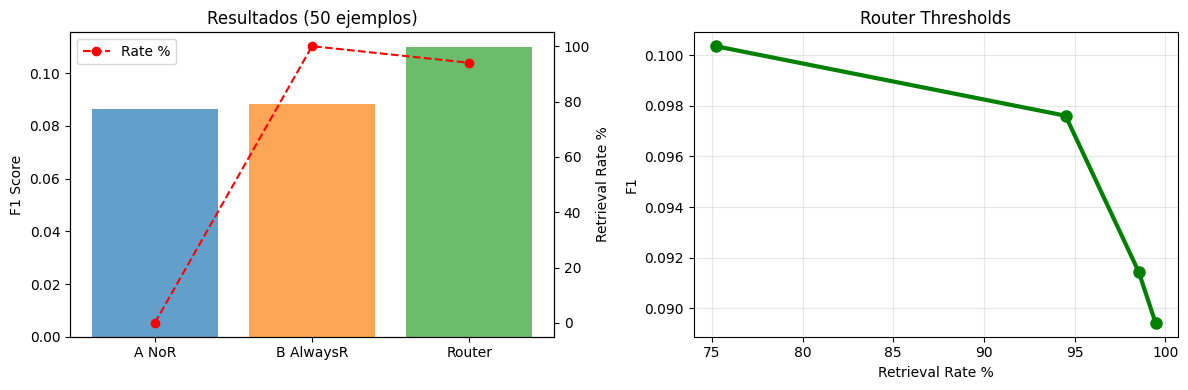

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(['A NoR', 'B AlwaysR', 'Router'], [f1A, f1B, 0.110], 
        color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
ax1.set_ylabel('F1 Score'); ax1.set_title('Resultados (50 ejemplos)')
ax2 = ax1.twinx()
ax2.plot(['A NoR', 'B AlwaysR', 'Router'], [0, 100, 94], 'r--o', label='Rate %')
ax2.set_ylabel('Retrieval Rate %'); ax2.legend(loc='upper left')

thresh_rates = [r['retrieval_rate']*100 for r in results]
ax3 = plt.subplot(1,2,2)
ax3.plot(thresh_rates, [r['F1'] for r in results], 'go-', linewidth=3, markersize=8)
ax3.set_xlabel('Retrieval Rate %'); ax3.set_ylabel('F1'); ax3.set_title('Router Thresholds')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adaptive_rag_results.png', dpi=300, bbox_inches='tight')
plt.show()